In [2]:
def MCP_Neurons_AND(X1, X2, T):
    assert len(X1) == len(X2)

    state_neuron = []

    for i in range(len(X1)):
        s = X1[i] + X2[i]

        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# Example
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2

print(MCP_Neurons_AND(X1, X2, T))

[0, 0, 0, 1]


In [3]:
def MCP_Neurons_OR(X1, X2, T):
    assert len(X1) == len(X2)

    state_neuron = []

    for i in range(len(X1)):
        s = X1[i] + X2[i]

        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

T = 1
print(MCP_Neurons_OR(X1, X2, T))

[0, 1, 1, 1]


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
df_0_1 = pd.read_csv("/content/drive/MyDrive/AI ML/Data/mnist_0_and_1.csv")  # adjust path if needed

X = df_0_1.drop(columns=["label"]).values
y = df_0_1["label"].values

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


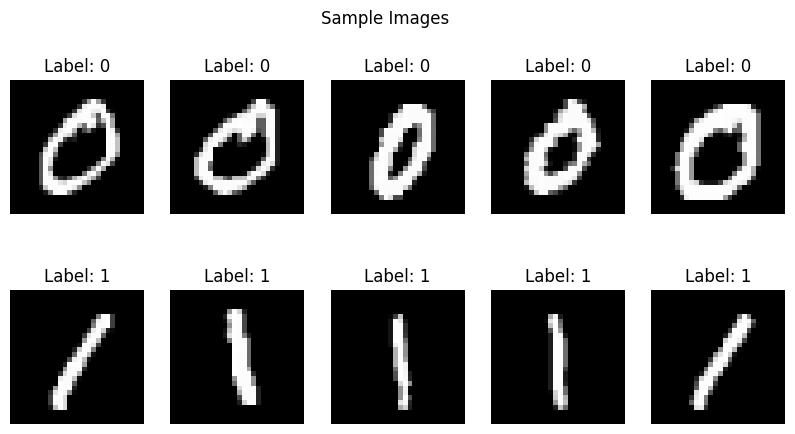

In [7]:
images_0 = X[y == 0]
images_1 = X[y == 1]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i in range(5):
    axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("Label: 0")
    axes[0, i].axis("off")

    axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Label: 1")
    axes[1, i].axis("off")

plt.suptitle("Sample Images")
plt.show()

In [8]:
weights = np.zeros(X.shape[1])  # 784 weights
bias = 0

learning_rate = 0.1
epochs = 100

In [9]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):

    for epoch in range(epochs):
        correct = 0

        for i in range(len(X)):
            z = np.dot(X[i], weights) + bias

            y_pred = 1 if z >= 0 else 0

            if y_pred == y[i]:
                correct += 1
            else:
                # Update weights
                weights = weights + learning_rate * (y[i] - y_pred) * X[i]

                # Update bias
                bias = bias + learning_rate * (y[i] - y_pred)

        accuracy = correct / len(X)
        print(f"Epoch {epoch+1}: Accuracy = {accuracy:.4f}")

    return weights, bias, accuracy

In [10]:
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

print("Final Accuracy:", accuracy)

Epoch 1: Accuracy = 0.9967
Epoch 2: Accuracy = 0.9982
Epoch 3: Accuracy = 0.9987
Epoch 4: Accuracy = 0.9987
Epoch 5: Accuracy = 0.9990
Epoch 6: Accuracy = 0.9993
Epoch 7: Accuracy = 0.9998
Epoch 8: Accuracy = 0.9995
Epoch 9: Accuracy = 0.9989
Epoch 10: Accuracy = 0.9992
Epoch 11: Accuracy = 0.9995
Epoch 12: Accuracy = 0.9998
Epoch 13: Accuracy = 1.0000
Epoch 14: Accuracy = 1.0000
Epoch 15: Accuracy = 1.0000
Epoch 16: Accuracy = 1.0000
Epoch 17: Accuracy = 1.0000
Epoch 18: Accuracy = 1.0000
Epoch 19: Accuracy = 1.0000
Epoch 20: Accuracy = 1.0000
Epoch 21: Accuracy = 1.0000
Epoch 22: Accuracy = 1.0000
Epoch 23: Accuracy = 1.0000
Epoch 24: Accuracy = 1.0000
Epoch 25: Accuracy = 1.0000
Epoch 26: Accuracy = 1.0000
Epoch 27: Accuracy = 1.0000
Epoch 28: Accuracy = 1.0000
Epoch 29: Accuracy = 1.0000
Epoch 30: Accuracy = 1.0000
Epoch 31: Accuracy = 1.0000
Epoch 32: Accuracy = 1.0000
Epoch 33: Accuracy = 1.0000
Epoch 34: Accuracy = 1.0000
Epoch 35: Accuracy = 1.0000
Epoch 36: Accuracy = 1.0000
E

In [11]:
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

Final Accuracy: 1.0000


In [12]:
misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")

    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

All images were correctly classified!


In [14]:
df_3_5 = pd.read_csv("/content/drive/MyDrive/AI ML/Data/mnist_3_and_5.csv")

X = df_3_5.drop(columns=["label"]).values
y = df_3_5["label"].values

Task 1 – MCP Neurons

Question 1: Limitations of MCP Neurons

MCP neurons cannot learn from data (no training mechanism).

They use fixed weights and thresholds which must be manually defined.

They cannot solve non-linearly separable problems such as XOR.

They only work with binary inputs and outputs.

They lack adaptability and generalization ability.

They do not support optimization or error correction.

Question 2: Can MCP solve XOR?

A single MCP neuron cannot solve the XOR problem because XOR is not linearly separable.

However, XOR can be expressed using logical operations:

XOR = (A OR B) AND (NOT (A AND B))

This requires multiple MCP neurons, not a single one.



Task 2 – Perceptron (0 vs 1)

Question 1: What does the shape of X represent?

The shape of X represents:

Number of rows represents number of samples (images).
Number of columns represents number of features (pixels).

For MNIST:

Each row has one image and each image has 784 features (28×28 pixels)

Question 2: (Duplicate in sheet, answer properly)

The shape of X indicates the dataset structure:
(n_samples,n_features).
It shows how many images are present and how many pixel values each image contains.

Question 3: What does the weights array represent?
The weights array represents:

The importance of each feature (pixel)
Each weight corresponds to one pixel in the image.
It determines how much influence each pixel has on the final prediction

Question 4: Why initialize weights to zero?

Weights are initialized to zero for simplicity and consistency.

Effect:

Provides a neutral starting point
Ensures all features start equally
The perceptron will update weights during training based on errors

Question 5: Purpose of np.dot(X[i], weights) + bias.

This line computes the weighted sum of inputs, which:

Combines input features with their weights

Adds bias to shift decision boundary

Produces the value used to make prediction

Question 6: What happens when prediction is wrong?

When prediction is incorrect:

The weights are updated using:

w = w + η(y − ŷ)x

The bias is updated using:

b = b + η(y − ŷ)

This helps the model move toward the correct classification.

Question 7: Why is final accuracy important?

Measures how well the model performs
Indicates percentage of correct predictions
Helps evaluate model effectiveness

Expected result:

For 0 vs 1 → accuracy should be very high (close to 100%) because the data is linearly separable.

Question 8: What does misclassified_idx store?

mThe isclassified_idx stores that the indices of data points where prediction ≠ actual label. These indices are used to visualize incorrectly classified images.

Question 9: Interpretation of “All images were correctly classified!”

This means that the model achieved 100% accuracy and there are no misclassifications.
The dataset is perfectly separable using a linear model.


Task 3 – Perceptron (3 vs 5)
Final Conclusion

The perceptron performs worse when classifying digits 3 and 5 compared to 0 and 1. This is because digits 3 and 5 have similar shapes, making them harder to separate using a linear decision boundary. As a result, some images are misclassified. This demonstrates the limitation of the perceptron in handling non-linearly separable data.